In [19]:
# --- Imports
from pathlib import Path
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge


import matplotlib.pyplot as plt

# --- Reproducibility
RNG = 42
np.random.seed(RNG)

# --- Config (match your script)
MAZE_KEY = "LM8"       # change if needed
NETWORK_SIZE = 10     # pick one from: 10, 25, 50, 75, 100, 250, 500, 750

# Jupyter-safe repo root (no __file__)
REPO_ROOT = Path.cwd().parents[2]  # adjust if your notebook is deeper/shallower
ACTIVATIONS_OUT = REPO_ROOT / f"data/activations/activations_{MAZE_KEY}.pkl"

# --- Load activations dict: {n_pcs: DataFrame[x, y, pc_*]}
with open(ACTIVATIONS_OUT, "rb") as fh:
    act_dict = pickle.load(fh)

df = act_dict[NETWORK_SIZE].copy()
pc_cols = [c for c in df.columns if c.startswith("pc_")]
assert len(pc_cols) == NETWORK_SIZE, f"Expected {NETWORK_SIZE} pc_* columns, got {len(pc_cols)}"

X = df[pc_cols].to_numpy(dtype=np.float32)      # activations already in [0,1] per column
Y = df[["x","y"]].to_numpy(dtype=np.float32)    # target coordinates (meters)

print(f"Maze={MAZE_KEY}  N={X.shape[0]}  PCs={X.shape[1]}")


Maze=LM8  N=2963  PCs=10


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=RNG
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RNG
)
print(f"Train={X_tr.shape[0]}  Val={X_val.shape[0]}  Test={X_test.shape[0]}")


Train=1896  Val=474  Test=593


In [10]:
def euclidean_errors(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).sum(axis=1))

def summarize_errors(err):
    return {
        "mae": float(np.mean(err)),
        "median": float(np.median(err)),
        "p75": float(np.percentile(err, 75)),
        "p90": float(np.percentile(err, 90)),
        "max": float(np.max(err)),
        "n": int(err.size),
    }

In [21]:
# Fit scaler on TRAIN only
xsc = StandardScaler()
X_tr_s = xsc.fit_transform(X_tr)

# Transform val/test with the same scaler
X_val_s = xsc.transform(X_val)
X_test_s = xsc.transform(X_test)


In [22]:
def median_heuristic_gamma(X, max_samples=2000, rng=42):
    # gamma ≈ 1 / median(pairwise_sq_dist)
    n = X.shape[0]
    m = min(n, max_samples)
    idx = np.random.default_rng(rng).choice(n, size=m, replace=False)
    Z = X[idx]
    # pairwise squared distances (fast)
    G = Z @ Z.T
    s = np.sum(Z**2, axis=1, keepdims=True)
    D2 = s - 2*G + s.T
    tri = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(tri)
    return 1.0 / med if np.isfinite(med) and med > 0 else 1.0

gamma0 = median_heuristic_gamma(X_tr_s)
alpha0 = 1e-1
gamma0, alpha0


(np.float32(0.08242346), 0.1)

In [23]:
krr = KernelRidge(kernel="rbf", alpha=alpha0, gamma=gamma0)
krr.fit(X_tr_s, y_tr)  # multi-output (x,y) is handled directly


KernelRidge(alpha=0.1, gamma=np.float32(0.08242346), kernel='rbf')

In [24]:
y_val_hat = krr.predict(X_val_s)
val_err = euclidean_errors(y_val, y_val_hat)
summ_val = summarize_errors(val_err)
summ_val


{'mae': 0.06336715072393417,
 'median': 0.05121982842683792,
 'p75': 0.08331156522035599,
 'p90': 0.11914662271738052,
 'max': 0.34990569949150085,
 'n': 474}

In [25]:
alphas = [1e-2, 1e-1, 1.0]
gammas = [gamma0*0.3, gamma0, gamma0*3.0]

best = None
for a in alphas:
    for g in gammas:
        m = KernelRidge(kernel="rbf", alpha=a, gamma=g).fit(X_tr_s, y_tr)
        e = euclidean_errors(y_val, m.predict(X_val_s))
        mae = float(np.mean(e))
        if (best is None) or (mae < best["mae"]):
            best = {"alpha": a, "gamma": g, "mae": mae, "model": m}
best


{'alpha': 0.01,
 'gamma': np.float32(0.24727039),
 'mae': 0.03030489757657051,
 'model': KernelRidge(alpha=0.01, gamma=np.float32(0.24727039), kernel='rbf')}

In [26]:
# Stack train+val
X_trval_s = np.vstack([X_tr_s, X_val_s])
y_trval   = np.vstack([y_tr,   y_val])

# Refit with chosen hyperparams
krr_final = KernelRidge(kernel="rbf", alpha=best["alpha"], gamma=best["gamma"])
krr_final.fit(X_trval_s, y_trval)

# Evaluate on held-out test set
y_test_hat = krr_final.predict(X_test_s)
test_err = euclidean_errors(y_test, y_test_hat)
summ_test = summarize_errors(test_err)
summ_test


{'mae': 0.030097106471657753,
 'median': 0.02469336986541748,
 'p75': 0.04008728265762329,
 'p90': 0.05643969774246216,
 'max': 0.16158133745193481,
 'n': 593}

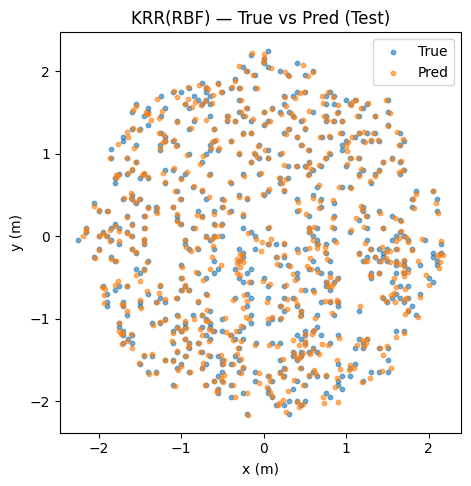

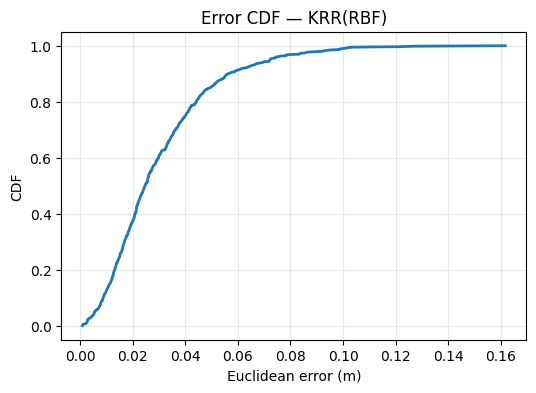

In [27]:
# True vs Predicted (test)
plt.figure(figsize=(5.2,5.2))
plt.scatter(y_test[:,0], y_test[:,1], s=10, alpha=0.6, label="True")
plt.scatter(y_test_hat[:,0], y_test_hat[:,1], s=10, alpha=0.6, label="Pred")
plt.gca().set_aspect("equal", adjustable="box")
plt.title("KRR(RBF) — True vs Pred (Test)")
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.legend(); plt.show()

# Error CDF
e_sorted = np.sort(test_err)
cdf = np.arange(1, e_sorted.size+1) / e_sorted.size
plt.figure(figsize=(6.0,4.0))
plt.plot(e_sorted, cdf, linewidth=2)
plt.xlabel("Euclidean error (m)"); plt.ylabel("CDF")
plt.title("Error CDF — KRR(RBF)")
plt.grid(True, alpha=0.3); plt.show()
